# Digit Recognition
Pipeline: **HOG + sklearn classifiers ⊕ 5× CNN ensemble with TTA** — soft-vote stacked.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
DATA_DIR = 'data'
IMG_SIZE = (28, 28)

_CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

_HOG = cv2.HOGDescriptor(
    _winSize=IMG_SIZE, _blockSize=(8, 8),
    _blockStride=(4, 4), _cellSize=(4, 4), _nbins=9
)

def find_train_image(img_id, category):
    path = os.path.join(DATA_DIR, 'train', 'train', str(category), f'{img_id}.png')
    if os.path.exists(path):
        return path
    for cat in range(10):
        p = os.path.join(DATA_DIR, 'train', 'train', str(cat), f'{img_id}.png')
        if os.path.exists(p):
            print(f'WARNING: image {img_id} found in class {cat}, expected class {category}')
            return p
    return None

def find_test_image(img_id):
    for candidate in [
        os.path.join(DATA_DIR, 'test', f'{img_id}.png'),
        *[os.path.join(DATA_DIR, 'test', 'test', str(c), f'{img_id}.png') for c in range(10)],
        os.path.join(DATA_DIR, 'test', 'test', f'{img_id}.png'),
    ]:
        if os.path.exists(candidate):
            return candidate
    return None

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'cv2.imread failed to load image: {path}')
    return cv2.resize(img, IMG_SIZE)

def preprocess(path):
    img = _CLAHE.apply(load_image(path))
    return _HOG.compute(img).flatten()

## Sample Images

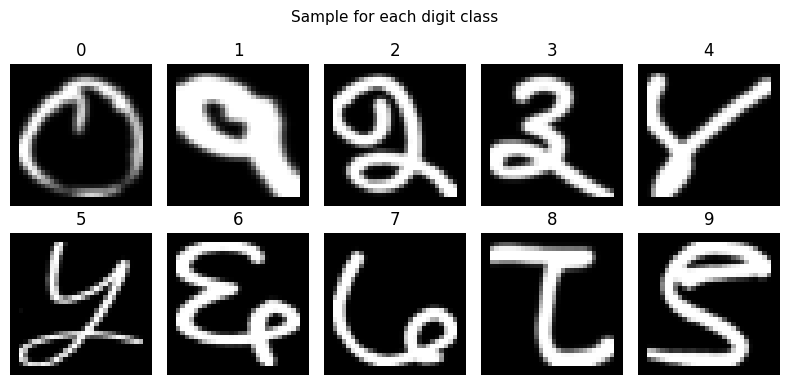

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
fig.suptitle('Sample for each digit class', fontsize=11)

for digit, ax in enumerate(axes.flat):
    row = train_df[train_df['Category'] == digit].iloc[0]
    path = find_train_image(row['Id'], row['Category'])
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(str(digit), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Load Training Data

17000 samples  HOG: 1296  raw: (28, 28)  0 missing


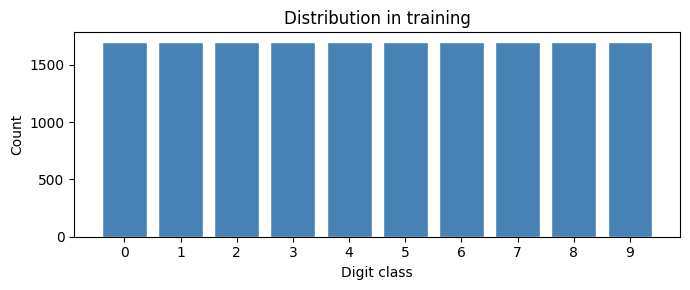

In [4]:
X_train, X_train_raw, y_train = [], [], []
missing = 0

for _, row in train_df.iterrows():
    path = find_train_image(row['Id'], row['Category'])
    if path is None:
        missing += 1
        continue
    img = load_image(path)
    X_train_raw.append(img)
    X_train.append(_HOG.compute(_CLAHE.apply(img)).flatten())
    y_train.append(int(row['Category']))

X_train     = np.array(X_train)
X_train_raw = np.array(X_train_raw, dtype=np.uint8)
y_train     = np.array(y_train)
print(f'{len(X_train)} samples  HOG: {X_train.shape[1]}  raw: {X_train_raw.shape[1:]}  {missing} missing')

fig, ax = plt.subplots(figsize=(7, 3))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar(unique, counts, color='steelblue', edgecolor='white')
ax.set_xlabel('Digit class'); ax.set_ylabel('Count')
ax.set_title('Distribution in training')
ax.set_xticks(unique)
plt.tight_layout(); plt.show()

## Train Classifier

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Set True to retrain from scratch; False to load cached models on re-runs
FORCE_RETRAIN = True
MODEL_PATH    = 'model.joblib'

indices = np.arange(len(y_train))
idx_tr, idx_val = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y_train
)
X_tr,     X_val     = X_train[idx_tr],     X_train[idx_val]
X_tr_raw, X_val_raw = X_train_raw[idx_tr], X_train_raw[idx_val]
y_tr,     y_val     = y_train[idx_tr],     y_train[idx_val]

use_raw_for_predict = False
use_ensemble        = False

if not FORCE_RETRAIN and os.path.exists(MODEL_PATH):
    print('Loading saved sklearn model — skipping training')
    clf = joblib.load(MODEL_PATH)
    train_acc = np.mean(clf.predict(X_tr) == y_tr)
    val_acc   = np.mean(clf.predict(X_val) == y_val)
    print(f'Loaded  train: {train_acc:.2%}  val: {val_acc:.2%}')
else:
    candidates = {
        'SGD (linear)': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    SGDClassifier(loss='hinge', max_iter=50000,
                                     early_stopping=True, random_state=42, n_jobs=-1))
        ]),
        'SVC (RBF)': GridSearchCV(
            Pipeline([('scaler', StandardScaler()),
                      ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
            {'clf__C':     [1, 10, 50, 100],
             'clf__gamma': ['scale', 0.001, 0.005, 0.01]},
            cv=3, n_jobs=-1
        ),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ]),
    }

    results = {}
    for name, pipeline in candidates.items():
        pipeline.fit(X_tr, y_tr)
        tr_acc = np.mean(pipeline.predict(X_tr) == y_tr)
        v_acc  = np.mean(pipeline.predict(X_val) == y_val)
        results[name] = {'model': pipeline, 'train_acc': tr_acc, 'val_acc': v_acc}
        print(f'{name:20s}  train: {tr_acc:.2%}  val: {v_acc:.2%}')

    best_name = max(results, key=lambda k: results[k]['val_acc'])
    clf       = results[best_name]['model']
    train_acc = results[best_name]['train_acc']
    val_acc   = results[best_name]['val_acc']
    print(f'\nBest sklearn: {best_name}  (val {val_acc:.2%})')
    joblib.dump(clf, MODEL_PATH)
    print(f'Saved to {MODEL_PATH}')

cv_model  = clf.best_estimator_ if hasattr(clf, 'best_estimator_') else clf
cv_scores = cross_val_score(cv_model, X_train, y_train, cv=5, n_jobs=-1)
print(f'\nCross-validation (5-fold): {cv_scores.mean():.2%} +/- {cv_scores.std():.2%}')


SGD (linear)          train: 99.43%  val: 98.24%


## CNN Ensemble with Augmentation + TTA
Five independently-seeded CNNs with batch-norm, global average pooling, AdamW + cosine LR,
label smoothing, RandomAffine + RandomErasing augmentation. Soft-voted, with test-time
augmentation (TTA) at inference.

In [ ]:
CNN_DIR           = 'cnn_models'
N_MODELS          = 5
CNN_EPOCHS        = 20
CNN_BATCH_SIZE    = 128
CNN_TTA_PASSES    = 8
FORCE_RETRAIN_CNN = FORCE_RETRAIN

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms
    HAS_TORCH = True
except ImportError:
    HAS_TORCH   = False
    cnn         = None
    cnn_val_acc = 0.0
    print('PyTorch not installed — skipping CNN. Pipeline will use sklearn only.')

if HAS_TORCH:
    device = torch.device(
        'cuda' if torch.cuda.is_available()
        else 'mps' if torch.backends.mps.is_available()
        else 'cpu'
    )
    print(f'Using device: {device}')
    os.makedirs(CNN_DIR, exist_ok=True)

    eval_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
    ])
    train_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomAffine(degrees=15, translate=(0.12, 0.12),
                                scale=(0.85, 1.15), shear=10),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.5, 2.0)),
    ])
    tta_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomAffine(degrees=8, translate=(0.07, 0.07),
                                scale=(0.92, 1.08)),
        transforms.ToTensor(),
    ])

    class DigitDataset(Dataset):
        def __init__(self, images, labels=None, tf=None):
            self.images = images
            self.labels = labels
            self.tf = tf if tf is not None else eval_tf
        def __len__(self):
            return len(self.images)
        def __getitem__(self, i):
            x = self.tf(self.images[i])
            if self.labels is None:
                return x
            return x, int(self.labels[i])

    class StrongCNN(nn.Module):
        def __init__(self, dropout=0.4):
            super().__init__()
            def block(in_c, out_c):
                return nn.Sequential(
                    nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                    nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                    nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
                    nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                )
            self.b1 = block(1, 32)
            self.b2 = block(32, 64)
            self.b3 = nn.Sequential(
                nn.Conv2d(64, 128, 3, padding=1, bias=False),
                nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            )
            self.pool   = nn.MaxPool2d(2)
            self.drop2d = nn.Dropout2d(0.25)
            self.gap    = nn.AdaptiveAvgPool2d(1)
            self.head   = nn.Sequential(
                nn.Flatten(),
                nn.Dropout(dropout),
                nn.Linear(128, 256),
                nn.BatchNorm1d(256), nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(256, 10),
            )
        def forward(self, x):
            x = self.drop2d(self.pool(self.b1(x)))
            x = self.drop2d(self.pool(self.b2(x)))
            x = self.b3(x)
            x = self.gap(x)
            return self.head(x)

    class CNNEnsemble:
        """Soft-vote ensemble over StrongCNN models with optional TTA.
        Mirrors the sklearn predict / predict_proba interface."""
        def __init__(self, models, device, n_tta=0):
            self.models = models
            self.device = device
            self.n_tta  = n_tta

        def _forward(self, model, X_raw, tf, batch_size=256):
            model.eval()
            ds     = DigitDataset(X_raw, tf=tf)
            loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
            probs  = []
            with torch.no_grad():
                for xb in loader:
                    xb = xb.to(self.device)
                    probs.append(F.softmax(model(xb), dim=1).cpu().numpy())
            return np.concatenate(probs, axis=0)

        def predict_proba(self, X_raw):
            total, n = None, 0
            for m in self.models:
                p     = self._forward(m, X_raw, eval_tf)
                total = p if total is None else total + p
                n    += 1
                for _ in range(self.n_tta):
                    total = total + self._forward(m, X_raw, tta_tf)
                    n    += 1
            return total / n

        def predict(self, X_raw):
            return self.predict_proba(X_raw).argmax(axis=1)

    def train_one(seed):
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        model        = StrongCNN().to(device)
        train_ds     = DigitDataset(X_tr_raw, y_tr, tf=train_tf)
        train_loader = DataLoader(train_ds, batch_size=CNN_BATCH_SIZE,
                                  shuffle=True, drop_last=False)
        opt     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CNN_EPOCHS)
        loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)
        for epoch in range(1, CNN_EPOCHS + 1):
            model.train()
            running = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                opt.step()
                running += loss.item() * xb.size(0)
            sched.step()
            if epoch == 1 or epoch % 5 == 0 or epoch == CNN_EPOCHS:
                print(f'  seed {seed}  ep {epoch:2d}/{CNN_EPOCHS}  '
                      f'loss {running/len(train_ds):.4f}  '
                      f'lr {sched.get_last_lr()[0]:.5f}')
        return model

    models = []
    for i in range(N_MODELS):
        ckpt = os.path.join(CNN_DIR, f'cnn_{i}.pt')
        if not FORCE_RETRAIN_CNN and os.path.exists(ckpt):
            print(f'Loading cached CNN {i+1}/{N_MODELS}')
            m = StrongCNN().to(device)
            m.load_state_dict(torch.load(ckpt, map_location=device))
        else:
            print(f'Training CNN {i+1}/{N_MODELS}  (seed={42+i})')
            m = train_one(seed=42 + i)
            torch.save(m.state_dict(), ckpt)
            print(f'  saved {ckpt}')
        models.append(m)

    cnn      = CNNEnsemble(models, device, n_tta=CNN_TTA_PASSES)
    cnn_eval = CNNEnsemble(models, device, n_tta=0)

    val_no_tta    = float((cnn_eval.predict(X_val_raw) == y_val).mean())
    cnn_preds     = cnn.predict(X_val_raw)
    cnn_val_acc   = float((cnn_preds == y_val).mean())
    cnn_train_acc = float((cnn_eval.predict(X_tr_raw) == y_tr).mean())

    print(f'\nCNN ensemble ({N_MODELS} models)')
    print(f'  no TTA   val: {val_no_tta:.4%}')
    print(f'  with TTA val: {cnn_val_acc:.4%}')
    print(f'  train (no TTA): {cnn_train_acc:.4%}')


## Ensemble — SVC + CNN Soft Voting
Average class probabilities from both models. Works best when the two make different errors.

In [ ]:
sklearn_val_acc   = val_acc
sklearn_train_acc = train_acc
sklearn_clf       = clf

ens_val_acc  = -1.0
can_ensemble = HAS_TORCH and cnn is not None and hasattr(sklearn_clf, 'predict_proba')

if can_ensemble:
    sk_probs    = sklearn_clf.predict_proba(X_val)
    cnn_probs   = cnn.predict_proba(X_val_raw)
    ens_probs   = (sk_probs + cnn_probs) / 2
    ens_preds   = ens_probs.argmax(axis=1)
    ens_val_acc = float((ens_preds == y_val).mean())
    print(f'sklearn val:    {sklearn_val_acc:.4%}')
    print(f'CNN ens. val:   {cnn_val_acc:.4%}')
    print(f'sklearn+CNN:    {ens_val_acc:.4%}')
elif HAS_TORCH and cnn is not None:
    print(f'sklearn val:  {sklearn_val_acc:.4%}  (no predict_proba — soft-vote disabled)')
    print(f'CNN ens. val: {cnn_val_acc:.4%}')
else:
    print(f'sklearn val:  {sklearn_val_acc:.4%}  (CNN unavailable)')

scores = {'sklearn': sklearn_val_acc}
if HAS_TORCH and cnn is not None:
    scores['cnn'] = cnn_val_acc
if can_ensemble:
    scores['ensemble'] = ens_val_acc

best = max(scores, key=scores.get)
print(f'\nWinner: {best}  ({scores[best]:.4%})')

if best == 'ensemble':
    use_ensemble        = True
    use_raw_for_predict = False
    val_acc             = ens_val_acc
elif best == 'cnn':
    use_ensemble        = False
    use_raw_for_predict = True
    clf                 = cnn
    train_acc           = cnn_train_acc
    val_acc             = cnn_val_acc
else:
    use_ensemble        = False
    use_raw_for_predict = False


## Evaluation — Confusion Matrix

In [ ]:
if use_ensemble:
    ens_probs_val = (clf.predict_proba(X_val) + cnn.predict_proba(X_val_raw)) / 2
    preds_val     = ens_probs_val.argmax(axis=1)
else:
    X_eval    = X_val_raw if use_raw_for_predict else X_val
    preds_val = clf.predict(X_eval)

cm = confusion_matrix(y_val, preds_val)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix (validation set)')
plt.tight_layout(); plt.show()

print(classification_report(y_val, preds_val, digits=4))


## Predict Test Set

In [ ]:
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

test_ids, test_paths = [], []
for img_id in test_df['Id']:
    path = find_test_image(img_id)
    if path is None:
        print(f'WARNING: test image {img_id} not found — skipping')
        continue
    test_ids.append(img_id)
    test_paths.append(path)

# Load both representations for ensemble compatibility
test_X_raw = np.array([load_image(p) for p in test_paths], dtype=np.uint8)
test_X_hog = np.array([preprocess(p) for p in test_paths])

if use_ensemble:
    svc_probs   = clf.predict_proba(test_X_hog)
    cnn_probs   = cnn.predict_proba(test_X_raw)
    predictions = ((svc_probs + cnn_probs) / 2).argmax(axis=1)
elif use_raw_for_predict:
    predictions = clf.predict(test_X_raw)
else:
    predictions = clf.predict(test_X_hog)

submission = pd.DataFrame({'Id': test_ids, 'Category': predictions})
submission.to_csv('submission.csv', index=False)
print(f'Saved {len(submission)} to submission.csv')
print(f'Validation acc: {val_acc:.2%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

unique, counts = np.unique(predictions, return_counts=True)
axes[0].bar(unique, counts, color='coral', edgecolor='white')
axes[0].set_xlabel('Predicted digit'); axes[0].set_ylabel('Count')
axes[0].set_title('Prediction distribution on test set')
axes[0].set_xticks(unique)

axes[1].barh(['Train', 'Validation'], [train_acc * 100, val_acc * 100],
             color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_xlim(0, 105)
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_title('Accuracy summary')
for i, v in enumerate([train_acc, val_acc]):
    axes[1].text(v * 100 + 0.5, i, f'{v:.2%}', va='center', fontsize=11)

plt.tight_layout(); plt.show()
